In [1]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from loguru import logger


#1. 构建子图
#1.1 声明子图的状态
class SubgraphState(TypedDict):
    raw_text: str  #未清洗的文本
    stripped_text: str  # 去除首尾的空格
    punctuated_text: str  # 句尾添加句号


#1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text": stripped_text
    }


#1.3 添加句号的节点
def subgraph_punctuated_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text": punctuated_text
    }


#1.4 构建子图
builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuated_node", subgraph_punctuated_node)
builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuated_node")
builder.add_edge("subgraph_punctuated_node", END)
subgraph = builder.compile()


In [4]:
# 2、构建父图
# 2.1 声明状态
class ParentState(TypedDict):
    input_text: str
    cleaned_text: str


# 2.2 声明节点，调用子图
def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]
    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }


# 2.3 构建父图
parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node("call_subgraph", call_subgraph)
parent_builder.add_edge(START, "call_subgraph")
parent_builder.add_edge("call_subgraph", END)

# 添加检查点信息
checkpointer = InMemorySaver()
parent_graph = parent_builder.compile(checkpointer=checkpointer)

# 添加检查点后，必须填写config
config = {"configurable": {"thread_id": "123"}}

# 2.4 调用父图， 内部函数会调用子图
res = parent_graph.invoke({"input_text": " langgraph 真好玩   "}, config=config)
print(res)

2026-08-05 09:27:19.972 | INFO     | __main__:subgraph_strip_node:19 - 调用子图中的strip节点
2026-08-05 09:27:19.973 | INFO     | __main__:subgraph_punctuated_node:28 - 调用子图中的punctuated节点


{'input_text': ' langgraph 真好玩   ', 'cleaned_text': 'langgraph 真好玩。'}


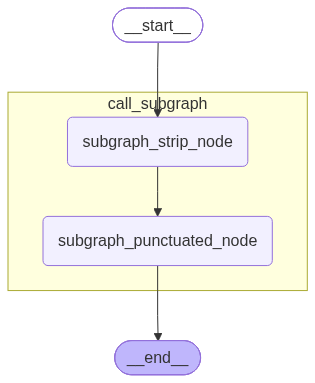

In [5]:
from IPython.display import display, Image

display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
histories = list(parent_graph.get_state_history(config=config))
histories

[StateSnapshot(values={'input_text': ' langgraph 真好玩   ', 'cleaned_text': 'langgraph 真好玩。'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1906cc-d428-6184-8001-e16d48bc469b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-05T01:27:19.975147+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1906cc-d41f-600d-8000-36d545e397a2'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input_text': ' langgraph 真好玩   '}, next=('call_subgraph',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1906cc-d41f-600d-8000-36d545e397a2'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-05T01:27:19.971422+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1906cc-d41d-673e-bfff-4fda7eee0ccd'}}, tasks=(PregelTask(id='dd20c7d2-5f3d-182c-19cb-614e96ff337e', name='cal

In [8]:
parent_config = histories[-2].config
parent_config

{'configurable': {'thread_id': '123',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1906cc-d41f-600d-8000-36d545e397a2'}}

In [9]:
subgraph_config = histories[-2].tasks[0].state
subgraph_config

{'configurable': {'thread_id': '123',
  'checkpoint_ns': 'call_subgraph:dd20c7d2-5f3d-182c-19cb-614e96ff337e'}}

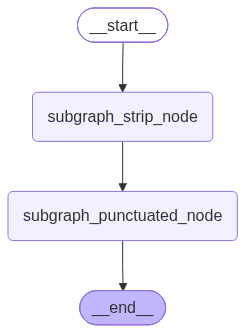

[StateSnapshot(values={'raw_text': ' langgraph 真好玩   ', 'stripped_text': 'langgraph 真好玩', 'punctuated_text': 'langgraph 真好玩。'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': 'call_subgraph:dd20c7d2-5f3d-182c-19cb-614e96ff337e', 'checkpoint_id': '1f1906cc-d425-6da2-8002-81c02ac77cad', 'checkpoint_map': {'': '1f1906cc-d41f-600d-8000-36d545e397a2', 'call_subgraph:dd20c7d2-5f3d-182c-19cb-614e96ff337e': '1f1906cc-d425-6da2-8002-81c02ac77cad'}}}, metadata={'source': 'loop', 'step': 2, 'parents': {'': '1f1906cc-d41f-600d-8000-36d545e397a2'}}, created_at='2026-08-05T01:27:19.974227+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': 'call_subgraph:dd20c7d2-5f3d-182c-19cb-614e96ff337e', 'checkpoint_id': '1f1906cc-d424-66ed-8001-acb2dd486288', 'checkpoint_map': {'': '1f1906cc-d41f-600d-8000-36d545e397a2', 'call_subgraph:dd20c7d2-5f3d-182c-19cb-614e96ff337e': '1f1906cc-d424-66ed-8001-acb2dd486288'}}}, tasks=(), interrupts=()),
 StateSnapshot(value

In [11]:
# 在检查点记录时 =》使用checkpoint_ns来区别不同的子图
display(subgraph)
list(parent_graph.get_state_history(config=subgraph_config))